##### **A. Plotting Fragment Length v/s Normalized Frequency**

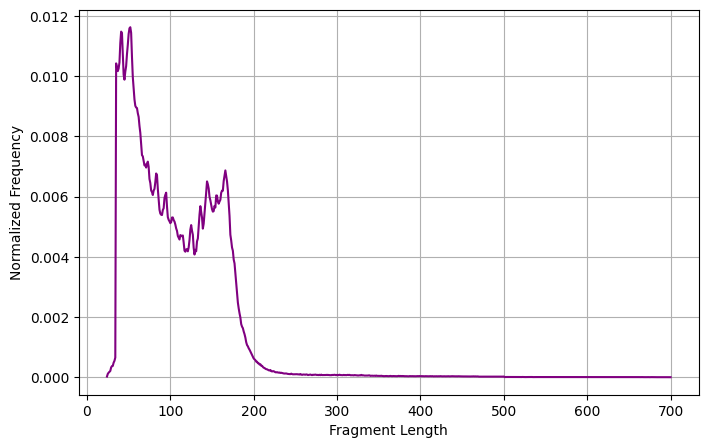

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

df = pd.read_csv('query.bed', sep='\t', header=None,low_memory=False)
counts = Counter(df.iloc[:, 2]-df.iloc[:,1])
total = sum(counts.values())
normalized_freq = {k: v / total for k, v in counts.items()}
# Sort the values by x (the difference) 
x, y = zip(*sorted(normalized_freq.items()))
df1 = pd.DataFrame({'Fragment Length': x, 'Normalized Frequency': y})
# Now plot
plt.figure(figsize=(8, 5))
plt.plot(df1.iloc[:,0], df1.iloc[:,1], color='purple')
plt.xlabel('Fragment Length')
plt.ylabel('Normalized Frequency')
plt.grid(True)
plt.show()


##### **B. Rescaling the Dataframe to the reference Dataset**
The approach used to rescale the two datasets is that the datasets are divided into bins then the occurence of the elements in the bins is counted for both the query and refernce dataset. After this a new dataset is created which for a given bin contain 'k' random values from the query dataset where k is the minimum of count of values in the given for the query and reference dataset. For example if the query dataset contains 15 elements in the bin 20-30 and the reference dataset contains 7 then the new dataset contains 7 random values from the query dataset in the range 20 to 30(30 is excluded).
This simple strategy rescales the query dataset to the reference where the new dataset created in the rescaled version of the query dataset. 

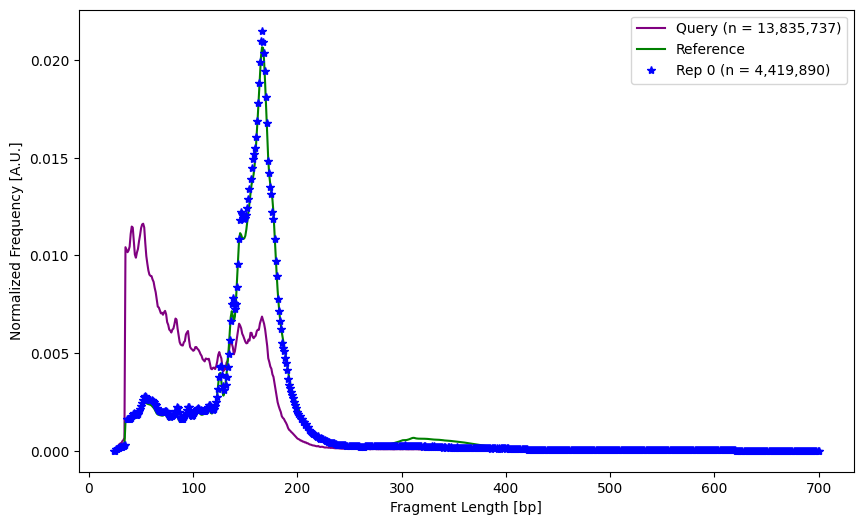

In [ ]:
ref_df = pd.read_csv('reference.hist', sep='\t', header=None, names=['Fragment Length', 'Frequency'])
query_df = pd.DataFrame({'Fragment Length': df.iloc[:, 2]-df.iloc[:,1]})
bin_edges = ref_df['Fragment Length'].values
query_df['bin'] = pd.cut(query_df['Fragment Length'], bins=np.append(bin_edges, bin_edges[-1]+1), labels=False, include_lowest=True)
subsampled_fragments = []

np.random.seed(42)
for i in range(len(ref_df)):
    bin_fragments = query_df[query_df['bin'] == i]
    if bin_fragments.empty:
        continue
    
    desired_fraction = ref_df.loc[i, 'Frequency']
    total_samples = int(desired_fraction * len(query_df) * 0.3346807)  
    
    if total_samples < len(bin_fragments):
        sampled = bin_fragments.sample(n=total_samples, replace=False)
    else:
        sampled = bin_fragments  
    
    subsampled_fragments.append(sampled)

# Merge all subsampled fragments
subsampled_df = pd.concat(subsampled_fragments)

# Plotting the histograms
query_hist, _ = np.histogram(query_df['Fragment Length'], bins=np.append(bin_edges, bin_edges[-1]+1))
query_hist = query_hist / query_hist.sum()

subsampled_hist, _ = np.histogram(subsampled_df['Fragment Length'], bins=np.append(bin_edges, bin_edges[-1]+1))
subsampled_hist = subsampled_hist / subsampled_hist.sum()

plt.figure(figsize=(10, 6))
plt.plot(bin_edges, query_hist, label=f'Query (n = {len(query_df):,})', color='purple')
plt.plot(ref_df['Fragment Length'], ref_df['Frequency'], label='Reference', color='green')
plt.plot(bin_edges, subsampled_hist, label=f'Rep 0 (n = {len(subsampled_df):,})', marker='*', linestyle='None', color='blue')
plt.xlabel('Fragment Length [bp]')
plt.ylabel('Normalized Frequency [A.U.]')
plt.legend()
plt.show()